In [12]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

from xgboost import XGBClassifier

In [13]:
df = pd.read_excel('../Anthrovision Dataset/anthrovision_data.xlsx')
df.shape

(2389, 17)

In [14]:
feature_cols = [
    "Height","Weight","Gender","MUAC","HC",
    "Age","BMI","BMIz_who","wfa_zscore","hfa_zscore"
]

df = df.dropna(subset=feature_cols + ["binary_label","multiclass_label"])
df["Gender"] = df["Gender"].astype("category").cat.codes
df["multiclass_label"] = df["multiclass_label"].astype("category").cat.codes
df["binary_label"] = df["binary_label"].map({"healthy":0,"malnourished":1})

In [15]:
X = df[feature_cols]
y_bin = df["binary_label"]
y_multi = df["multiclass_label"]

X_train, X_test, yb_train, yb_test = train_test_split(
    X, y_bin, test_size=0.2, stratify=y_bin, random_state=42
)

_, _, ym_train, ym_test = train_test_split(
    X, y_multi, test_size=0.2, stratify=y_multi, random_state=42
)

In [16]:
scaler_xgb = StandardScaler()
X_train_scaled = scaler_xgb.fit_transform(X_train)
X_test_scaled  = scaler_xgb.transform(X_test)

In [22]:
xgb_bin = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1.0,
    random_state=42
)
xgb_bin.fit(X_train_scaled, yb_train)

yb_pred = xgb_bin.predict(X_test_scaled)
acc = accuracy_score(yb_test, yb_pred)
prec = precision_score(yb_test, yb_pred)
rec = recall_score(yb_test, yb_pred)
f1 = f1_score(yb_test, yb_pred)

print("Binary XGBoost: \n")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-score: {f1:.4f}")

Binary XGBoost: 

Accuracy: 0.9979
Precision: 1.0000
Recall: 0.9932
F1-score: 0.9966


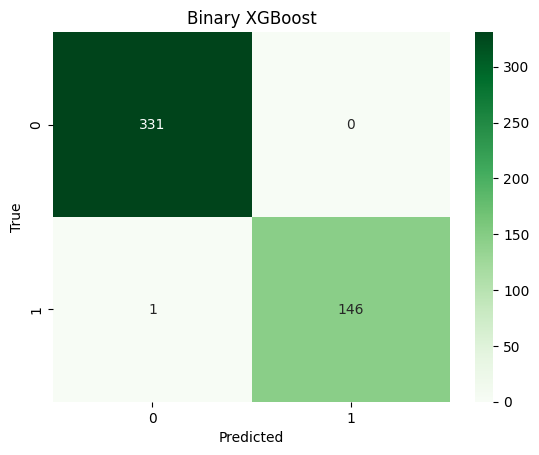

In [23]:
cm = confusion_matrix(yb_test, yb_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Binary XGBoost")
plt.show()

In [24]:
num_classes = df["multiclass_label"].nunique()

xgb_multi = XGBClassifier(
    objective="multi:softprob",
    num_class=num_classes,
    eval_metric="mlogloss",
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_multi.fit(X_train_scaled, ym_train)

ym_pred = xgb_multi.predict(X_test_scaled)
print("Multiclass XGBoost: \n")
acc = accuracy_score(ym_test, ym_pred)
prec = precision_score(ym_test, ym_pred, average='weighted')
rec = recall_score(ym_test, ym_pred, average='weighted')
f1 = f1_score(ym_test, ym_pred, average='weighted')

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-score: {f1:.4f}")

Multiclass XGBoost: 

Accuracy: 0.8222
Precision: 0.8051
Recall: 0.8222
F1-score: 0.8129


Text(0.5, 1.0, 'Multiclass XGBoost')

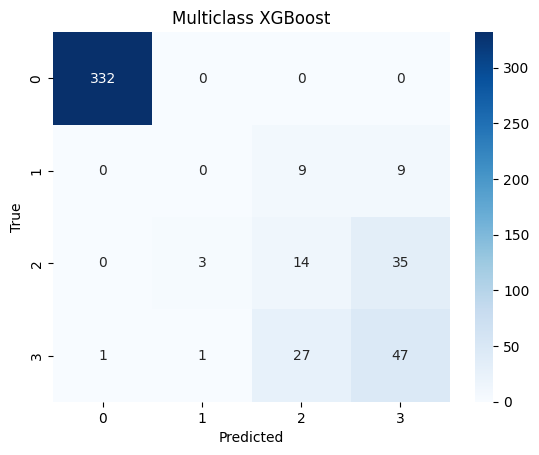

In [25]:
cm_multi = confusion_matrix(ym_test, ym_pred)
sns.heatmap(cm_multi, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Multiclass XGBoost")

In [26]:
joblib.dump(xgb_bin,   "xgb_binary.pkl")
joblib.dump(xgb_multi, "xgb_multiclass.pkl")
joblib.dump(scaler_xgb,"scaler_xgb.pkl")

['scaler_xgb.pkl']